# Basic Classification

Through this notebook, I will be following Chapter 3 of Hands-on Machine Learning, on classification.

This focuses on the MNIST dataset, containing 70,000 images of handwritten digits, a very common method to test new classification methods.

## 1. MNIST Data

We begin by fetching the MNIST dataset from Scikit-Learn. Datasets from Scikit-Learn typically contain:
- A DESCR key describing the dataset
- A data key containing an array with one row per instance and one column per feature
- A target key containing an array with labels

In [109]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

Let's have a look at some of the data contained in this set.

X has 70000 rows and 784 columns
y has 70000 rows


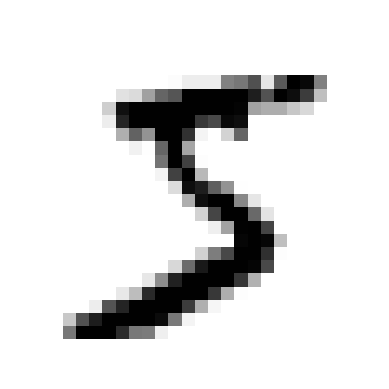

This image contains a 5


In [110]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

X, y = mnist["data"], mnist["target"]
print(f"X has {X.shape[0]} rows and {X.shape[1]} columns")
print(f"y has {y.shape[0]} rows")

# Note that, since X is a DataFrame, we need to select
# the relevant row (i.e. the first image), and then 
# convert it to a numpy array to visualize
first_digit = X.iloc[0].to_numpy()

# We know each image is 28x28 pixels, so
# we need to reshape it to visualize:
first_digit_image = first_digit.reshape(28, 28)

plt.imshow(first_digit_image, cmap="binary")
plt.axis("off")
plt.show()

print(f"This image contains a {y[0]}")

Since the y Series contains our labels, which are strictly numerical, we should check the datatype to make sure our classification algorithms, which will use integers, are correct:

In [111]:
type(y[0])

str

Since this is a string, we should convert the entire Series into integer values

In [112]:
y = y.astype(int)

As a test, I want to show a figure that contains a number of digits, like the one shown above.

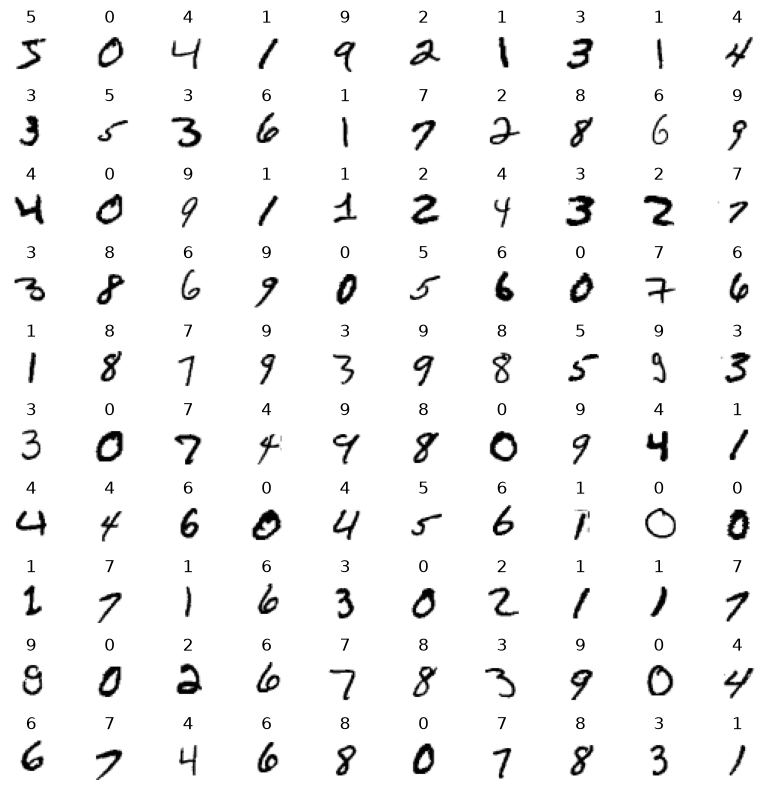

In [113]:
n = 10

digit_array = X.iloc[0:n*n].to_numpy()

digit_array_image = digit_array.reshape(-1, 28, 28)

fig, axes = plt.subplots(n, n, figsize=(8, 8))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digit_array_image[i], cmap="binary")
    ax.set_title(f"{y[i]}")
    ax.axis('off')  # Optional: hides the x/y axis ticks

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

### Train/Test Split
Before training any classifiers, we need to make sure that we have split our data into training and testing. We could do this by using train_test_split, but we know that the data is already shuffled, so we can simply select 80% of the data to set aside for training. Note that 80% of the data corresponds to the first 56,000 images.

In [114]:
split_point = 56000
X_train, X_test, y_train, y_test = X[:split_point], X[split_point:], y[:split_point], y[:split_point]

## 2. Training a Binary Classifier

We are first going to simply train a binary classifier that is capable of detecting the digit '3'. To do this, we will use *stochastic gradient descent*. 

### Basics of Stochastic Gradient Descent (SGD)
This is similar to gradient descent, which updates model parameters based on the gradient of the loss function at a particular point, moving inevitably towards a local minimum in the loss function's landscape.

Stochastic gradient descent is a variant of this general method where, instead of using the entire dataset to calculate the gradient, it calculates the gradient on a randomly selected batch (which could be a single data point). This has a number of benefits:
- It is faster and more scalable, as calculating the gradient on the entire dataset can be extremely slow
- It is less likely to get trapped in a local minimum that is not a global minimum due to the presence of stochasticity

The update rule is:
$$
\theta = \theta - \eta \nabla_\theta J(\theta;x_i,y_i)
$$
- $x_i$ and $y_i$ represent the features and target of the $i$-th training example
- the gradient $\nabla_\theta J(\theta;x_i,y_i)$ is calculated for a single data point or a small batch
- $\eta$ is an adjustable parameter to ensure the step size doesn't become too large

### Implementation

To begin, we mut first create our target vectors for this binary classification task, which consists of all the digits labelled with a particular number. The following code turns our training and testing labels into True and False labels:

In [115]:
num = 2
y_train_num = (y_train == num)
y_test_num = (y_test == num)

We now implement the SGD classifier from sklearn.linear_model:

In [116]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_num)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

Having performed a basic training of our classifier, let's now look at an array of data to get a feel for whether or not it is accurate

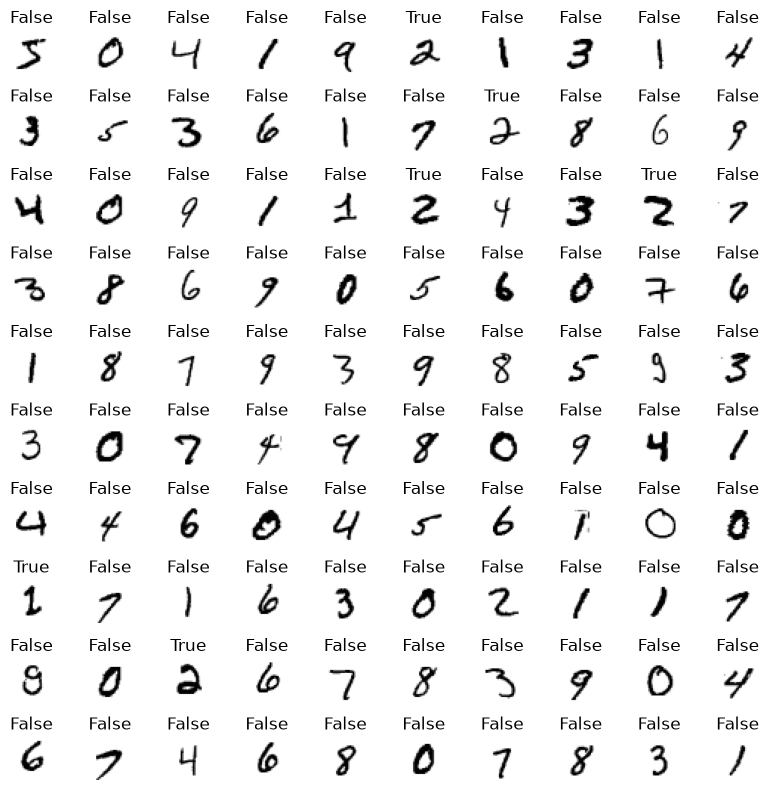

In [117]:
n = 10

X_array = X_train.iloc[0:n*n]
y_pred = sgd_clf.predict(X_array)

digit_array = X_train.iloc[0:n*n].to_numpy()

digit_array_image = digit_array.reshape(-1, 28, 28)

fig, axes = plt.subplots(n, n, figsize=(8, 8))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digit_array_image[i], cmap="binary")
    ax.set_title(f"{y_pred[i]}")
    ax.axis('off')  # Optional: hides the x/y axis ticks

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

We see that this algorithm has done quite a good job, with the occassional mis-labelling.

## 3. Performance Measures
Evaluating a classifier, unlike a regressor, can be quite tricky. There are a large number of ways that we can measure their performance. In the following, we go over:
- **3.a**. Cross-validation
- **3.b.** Confusion matrix
- **3.c.** Precision and Recall
- **3.d.** ROC Curve

### 3.a. Cross-Validation

We have gone over cross-validation previously. Recall that K-fold cross-validation means splitting the training set into K folds and then making predictions and evaluating them on each fold using a model trained on the remaining folds.

In [118]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_num, cv=3, scoring="accuracy")

array([0.96550062, 0.96823271, 0.96962392])

We have achieved a ~96% accuracy on each of the folds. Note that this is only classifying whether our image contains a single number or not, which is fairly straightforward. 

To understand why this is such a simple task, let us think about if we encoded an estimator that assumed that we never obtain the number that we are interested in, i.e. it always returns False.
This would achieve a 90% accuracy rating, since 90% of the data does not contain our single number. The extremely high accuracy of the above sample is therefore not that impressive.

This only works because we have chosen an *accuracy* measure, which is often not preferred. In particular, we have chosen an accuracy measure on a very skewed dataset, where the False class appears much more frequently than the others.

### 3.b. Confusion Matrix
The general idea of a *confusion matrix* is to count the number of times isntances of class A are mis-classified as class B. This is a matrix because if we want to find the number of times images of the number $m$ are mis-classified as number $n$, then we would look at the $m^{\mathrm{th}}$ row and the $n^{\mathrm{th}}$ column of our confusion matrix.

To compute this matrix, we need to have a set of predictions. Typically this would be done on the test set, but since we are in the stage where we are fine-tuning our model and not yet ready to fully evaluate it, we will instead obtain our predictions using *cross_val_predict*.

cross_val_predict generates cross-validated estimates for each input data point. The data is split according to the cv parameter, as usual. Each sample belongs to exactly one test set, and its prediction is computed with an estimator fitted on the corresponding training set. *Essentially*, this works just like cross_val_score(), performing K-fold cross-validation, but instead of returning the evaluation scores, it returns the predictions made on each test fold.

In [119]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_num, cv=3)

Using these predictions evaluated on the training set, we can now calculate the confusion matrix by passing the target classes (y_train_num) and the predicted classes (y_train_pred):

In [121]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_num, y_train_pred)

array([[49781,   659],
       [ 1145,  4415]])

This is a $2\times 2$ matrix, since we can only classify as True or False, and whether the prediction is Correct or Incorrect:
$$
\begin{matrix}
\mathrm{true \, negative} & \mathrm{false\, positive} \\
\mathrm{false\, negative} & \mathrm{true \,positive}
\end{matrix}
$$
Noting that, if our result was perfect, we would have only diagonal elements populated.

This contains a lot of information, as is not necessarily easy to compare across models or datasets. So we can look instead at the *precision*:
$$
\mathrm{precision} = \frac{\mathrm{TP}}{\mathrm{TP + FP}}
$$
and the *recall*:
$$
\mathrm{recall} = \frac{\mathrm{TP}}{\mathrm{TP + FN}}
$$
which are typically used together, as they can both be hacked independently.

We go into further detail of the precision and recall metrics in the following section.

### 3.c. Precision and Recall

The precision and recall matrics are accessed from the sklearn.metrics library:

In [125]:
from sklearn.metrics import precision_score, recall_score
print(f"precision = {precision_score(y_train_num, y_train_pred)}")
print(f"recall = {recall_score(y_train_num, y_train_pred)}")

precision = 0.8701221915648404
recall = 0.7940647482014388


These can be combined into the $F_1$ score:
$$
F_1 = \frac{2}{\frac{1}{\mathrm{precision}} + \frac{1}{\mathrm{recall}}} = 2\times \frac{\mathrm{precision \times recall}}{\mathrm{precision + recall}} = \frac{\mathrm{TP}}{\mathrm{TP} + \frac{\mathrm{FN + FP}}{2}}
$$
This classifier will only give a high score if *both* recall and precision are high.

In [126]:
from sklearn.metrics import f1_score
print(f"f1 score = {f1_score(y_train_num, y_train_pred)}")

f1 score = 0.8303554636072974


#### Precision/Recall Trade-Off
Unfortunately, as with most things in statistical learning, we cannot increase precision without reducing recall, and vice-versa. This is the essence of the precision/recall trade-off.

But first, it is important to understand in what situations precision and recall are individually valuable:
- In situations where we are mostly concerned with eliminating False Positives, we want high precision (i.e. in situations where we don't care about rejecting positives, as long as the ones that get through are definitely positive)
- In situations where we are concerned with eliminating False Negatives, we want a high recall (i.e. situations where we don't care about false positives, as long as we don't let any we don't accidentally classify a positive as a negative)

The *precision/recall trade-off* is rather easy to understand. First, we must understand that the score is based on the *decision function*, after calculating the score we assign our binary variable to either True or False based on where we position our *decision threshold*.

In theory, if we move the threshold:
- *Too high*: we will eliminate more false positives (increasing precision),
- *Too low*: we will eliminate more false negatives (increasing recall)
- *Just right*: we balance both.

We can actually visualize the precision/recall trade-off curve by assigning the threshold to the horizontal axis on a graph. This can be done by using *precision_recall_curve* from sklearn.metrics. To access this, we must pass method="decision_function" into our cross_val_predict, which means it returns the classifier's raw decision score instead of returning the predicted class label.

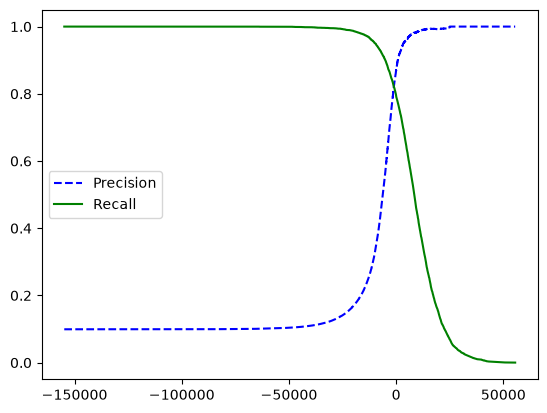

In [131]:
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(sgd_clf, X_train, y_train_num, cv=3,
                             method="decision_function")
precisions, recalls, thresholds = precision_recall_curve(y_train_num, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.legend()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

This helps us choose an exact threshold for an optimal precision/recall trade-off. However, we cannot set this threshold directly. 

If we want to choose the decision threshold by hand, we cannot use the classifier's predict() method, and instead have to call its decision_function() method, which as noted above returns a score for each instance.


In [136]:
y_scores = sgd_clf.decision_function(X_train) # returns scores
threshold = 0 # set threshold for scores
y_pred = (y_scores > threshold) # assigns True to values above threshold
y_pred

array([False, False, False, ...,  True, False, False], shape=(56000,))

It may also be helpful to plot precision against recall. In practice, we would want to choose a threshold prior to the rapid decrease in precision (i.e. a Recall of ~0.7).

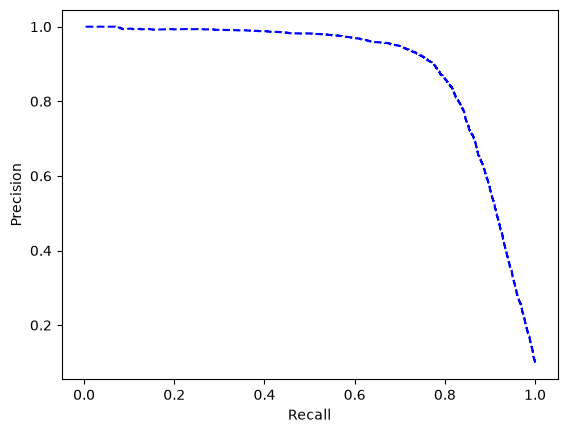

In [142]:
def plot_precision_vs_recall(precisions, recalls, thresholds):
    plt.plot(recalls[:-1], precisions[:-1], "b--")
    plt.xlabel("Recall")
    plt.ylabel("Precision")

plot_precision_vs_recall(precisions, recalls, thresholds)
plt.show()

### 3.d. Receiver Operating Characteristic (ROC) Curve 

As a general overview, the ROC curve is a graph that shows how well a binary classification model performs at every possible classification threshold. It's **key components** are:
- x-axis: False Positive Rate (FPR) = 1 - TNR = 1 - *specificity*
- y-axis True Positive Rate (TPR) = *sensitivity*
- Classification Threshold
- Random guessing line, which is perfectly linear at 45 degrees

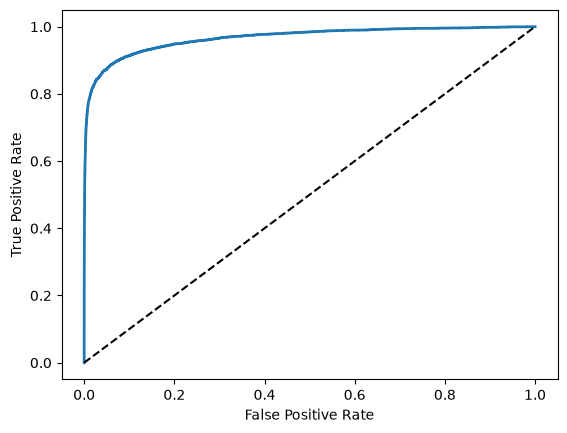

In [157]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_num, y_scores)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

plot_roc_curve(fpr, tpr)
plt.show()

A good measure is the *area under the curve (AUC)*:
- perfect classifier: AUC=1
- random classifier: AUC=0.5

Sklearn.metrics has a method for calculating the AUC:

In [158]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_num, y_scores)

0.9665057993256466

**Rule of thumb:** 
- use PR curve when positive class is rare OR you care more about false positives than false negatives
- otherwise use ROC curve

#### Random Forest Comparison
This is just a brief comparison, we will go over random forests in a later notebook.

However, here we note that this ML method does not have a decision_function() method, and instead uses predict_proba(), which gives the probability that the given instance belongs to the given class.

In [159]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_num, cv=3,
                                    method="predict_proba")

Now we compare the ROC curve of the random forest against our stochastic gradient descent model that we trained earlier:

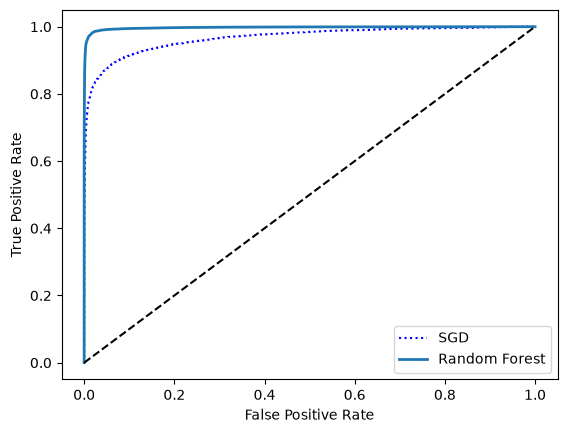

0.9973352109351377

In [164]:
y_scores_forest = y_probas_forest[:, 1] # score = probability of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_num, y_scores_forest)

plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

roc_auc_score(y_train_num, y_scores_forest)

We observe from the above that the random forest is a huge improvement over stochastic gradient descent. Both the ROC curve and the ROC AUC massively out-perform those obtained via SGD.

Finally, I want to plot an array of images, along with their associated predicted values.

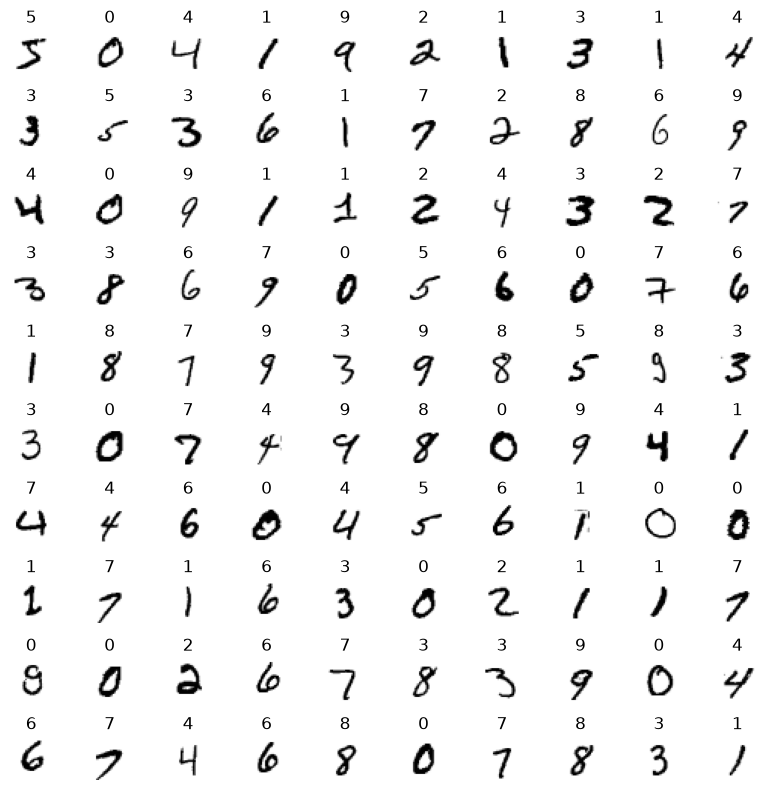

In [223]:
n = 10

X_array = X_train.iloc[0:n*n]
y_pred = sgd_clf.predict(X_array)

digit_array = X_train.iloc[0:n*n].to_numpy()

digit_array_image = digit_array.reshape(-1, 28, 28)

fig, axes = plt.subplots(n, n, figsize=(8, 8))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digit_array_image[i], cmap="binary")
    ax.set_title(f"{y_pred[i]}")
    ax.axis('off')  # Optional: hides the x/y axis ticks

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

## 4. Multiclass Classification

Here, we extend beyond simple binary classification to a multiclass classifier, so that we are able to classify each digit individually.

There are a number of methods that extend naturally to multiple classes (e.g. SGD, random forests, and naive Bayes. However, there are others that are strictly binary classifiers (e.g. logistic regression, support vector machines). We can extend binary classifiers to multiclass classification in two main ways:
- **one-versus-the-rest (OvR)**: a single-class classifier for each class, where final classification is achieved by taking the highest score, *generally preferred*
- **one-versus-one (OvO)**: a binary classifier operating between all combinations of classes, where final classification is achieved by taking the classifier that won the most duels, *preferred under poor scaling, e.g. SVM*.

Scikit-Learn detects when we are using binary classification for multiclass classification tasks, and automatically runs one of the above. Let's run a couple of classifiers and compare them.

**Training various models:**

In [165]:
# Support Vector Machine

from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train)

# SVM OvR
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)

# SGD
sgd_clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [177]:
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[SVC(), SVC(), SVC(), SVC(), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](784,)","['pixel1','pixel2','pixel3',...,'pixel782','pixel783','pixel784']"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,784


In [178]:
sgd_clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

**Compare model performance:**

In [180]:
# Testing: choose a digit from the training array
num_test = 5 # entry from training array
digit = X_train.iloc[[num_test]] # pick out test example

# SVM
print(f"SVM prediction: {svm_clf.predict(digit)}") # print our model's prediction
digit_scores = svm_clf.decision_function(digit) # all scores for our test value
print(f"SVM scores: {digit_scores}") # print scores, highest corresponds to our predicted value
print()

# SVM OvR
print(f"SVM OvR prediction: {ovr_clf.predict(digit)}") # print our model's prediction
digit_scores = ovr_clf.decision_function(digit) # all scores for our test value
print(f"SVM OvR scores: {digit_scores}") # print scores, highest corresponds to our predicted value
print()

# SGD
print(f"SGD prediction: {sgd_clf.predict(digit)}") # print our model's prediction
digit_scores = sgd_clf.decision_function(digit) # all scores for our test value
print(f"SGD scores: {digit_scores}") # print scores, highest corresponds to our predicted value


SVM prediction: [2]
SVM scores: [[ 2.73598113 -0.3008575   9.31378682  7.27007711  3.75187979  3.75750889
   0.71112842  2.77218715  8.27581919  6.22889258]]

SVM OvR prediction: [2]
SVM OvR scores: [[-2.04812035 -2.77329621  1.60317311 -1.18904024 -2.62351529 -2.42101589
  -2.43391569 -2.51782875 -1.36263465 -1.33432266]]

SGD prediction: [2]
SGD scores: [[ -4867.40265249 -51372.70559378   7248.4992542   -6867.07813259
  -15243.66875739 -12545.49530932 -30308.02143491 -23588.11111002
  -11233.4710359   -5114.39119283]]


**Cross-validation:**

In [184]:
# SVM
cross_val_score(svm_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.97562544, 0.97417903, 0.97224901])

In [183]:
# SVM OvR
cross_val_score(ovr_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.97578615, 0.97455403, 0.97235616])

In [182]:
# SGD
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87480581, 0.86869877, 0.86445944])

Pretty good on all fronts, with the SVM out-performing SGD. Note that if we used a purely random classifier, we would only get 10% accuracy, so these scores are quite good!

Final note, we can use the standard scaler to further improve our methods. This scales the individual pixel values, transforming each pixel to be centered around 0 with a std of 1, instead of having a pixel intensity between 0 and 255.

In [186]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

C:\Users\raymo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\raymo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\raymo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89907323, 0.90164461, 0.89858566])

A minor improvement that didn't converge in the maximum number of iterations, generally a good idea, but needs tweaking.


## 5. Error Analysis

From here on we will assume that we have chosen the sgd method for training our data in order to provide an error analysis.

We begin by looking at the confusion matrix.

In [190]:
# Predict using cross-validation (no standardization)
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

In [ ]:
# Calculate and print the confusion matrix
conf_mx = confusion_matrix(y_train, y_train_pred)
print(conf_mx)

# Visualise the confusion matrix
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

To look at the errors in more detail, we can normalize the error to the number of images in the corresponding class, which gives an **error rate**. And then fill the diagonal with zeros, since these will dominate the result for our trained model.

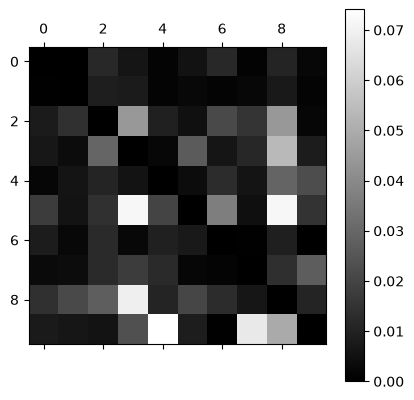

In [193]:
# Calculate number in each class
row_sums = conf_mx.sum(axis=1, keepdims=True)
# Normalize matrix
norm_conf_mx = conf_mx / row_sums
# Remove diagonal elements
np.fill_diagonal(norm_conf_mx, 0)
# Plot the results
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

**Recall:** what the above is showing you is that the (row) gets misclassified as (column) at the rate shown.

A useful method which we can use to improve our performance would be pre-processing the image data, to highlight important features.

## 6. Multilabel Classification
As a very brief tour of multilabel classification, we note that such models are useful when more than one instance appears in a single data point. Two examples are:
- identifying multiple digits in a single image
- identifying multiple faces in a single image

As an example of this, we will train a classifier to recognise when a number is either greater than 6, an odd number, or both. To do this we will use K Nearest Neighbors, which supports multilabel classification.

In [198]:
from sklearn.neighbors import KNeighborsClassifier

y_train_gtr_6 = (y_train > 6)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_gtr_6, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

[[False False]]
   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
5       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
5        0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
5         0         0         0         0  

[1 rows x 784 columns]


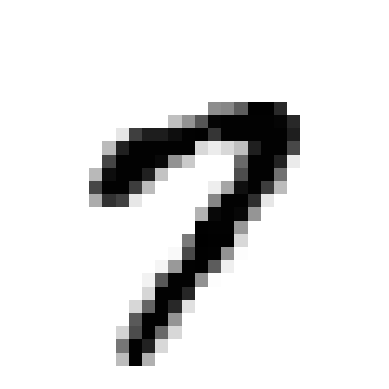

is greater than 6: True, is odd: True


In [220]:
digit_loc = 15

digit = X.iloc[[digit_loc]]

digit_np = digit.to_numpy()
digit_image = digit_np.reshape(28, 28)

plt.imshow(digit_image, cmap="binary")
plt.axis("off")
plt.show()

multilabel_pred = knn_clf.predict(digit)
print(f"is greater than 6: {multilabel_pred[0][0]}, is odd: {multilabel_pred[0][1]}")